# Analisis Probabilitas Hujan di Nusa Tenggara Timur (NTT)
### Periode 1985–2015 | Data ERA5 Reanalysis × ONI NOAA

---

## Latar Belakang

Nusa Tenggara Timur (NTT) merupakan salah satu wilayah di Indonesia yang memiliki pola hujan yang sangat dipengaruhi oleh kondisi iklim global, khususnya fenomena **El Niño – La Niña** yang diukur melalui indeks **ONI (*Oceanic Niño Index*)**.

- **El Niño** (ONI > +0.5) → cenderung menyebabkan **musim kering yang lebih panjang** di NTT.
- **La Niña** (ONI < -0.5) → cenderung menyebabkan **curah hujan yang lebih tinggi** dari normal.

---

## Tujuan Analisis

1. Memproses data curah hujan dari ERA5 Reanalysis dan data indeks ONI dari NOAA
2. Menghitung probabilitas hujan per musim dan per titik grid spasial di wilayah NTT
3. Menganalisis korelasi antara probabilitas hujan dan indeks ONI per musim
4. Memvisualisasikan sebaran spasial probabilitas hujan seluruh wilayah NTT
5. Mengekspor data untuk digunakan di dashboard interaktif

---

## Pembagian Musim

| Kode | Bulan | Keterangan |
|------|-------|------------|
| **JFM** | Januari – Maret | Puncak musim hujan |
| **AMJ** | April – Juni | Transisi hujan ke kering |
| **JAS** | Juli – September | Musim kering |
| **OND** | Oktober – Desember | Awal musim hujan |

---

## Definisi Probabilitas Hujan

- Setiap hari dikategorikan: **hujan** jika curah hujan > 0.5 mm, **tidak hujan** jika ≤ 0.5 mm
- Probabilitas per musim = persentase hari hujan dari total hari dalam musim tersebut

**Contoh:** Jika dalam musim JFM (90 hari) ada 54 hari hujan → probabilitas = 60%

---
## Bagian 1: Import Library

**Tujuan:** Memuat semua pustaka Python yang diperlukan.

- `numpy`, `pandas` → pengolahan data numerik dan tabel
- `matplotlib`, `seaborn` → visualisasi grafik dan heatmap
- `xarray` → membaca file NetCDF dari ERA5
- `geopandas`, `shapely` → membaca shapefile batas wilayah
- `sklearn` → normalisasi data dan regresi linear

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import xarray as xr
from shapely.geometry import Point
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

---
## Bagian 2: Load dan Pembersihan Data ONI

**Tujuan:** Membaca data ONI dari NOAA, membuang kolom musim yang tidak digunakan, dan memfilter periode 1985–2015.

- **Kolom dipertahankan:** `Year`, `JFM`, `AMJ`, `JAS`, `OND`
- **Kolom dihapus:** `DJF`, `FMA`, `MAM`, `MJJ`, `JJA`, `ASO`, `SON`, `NDJ` (musim tumpang tindih)

In [2]:
data = pd.read_csv('C:/Metklim pbl/ONI.csv')
data

,Year,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
0,1950,-1.4,-1.2,-1.1,-1.2,-1.1,-0.9,-0.6,-0.6,-0.5,-0.6,-0.7,-0.8
1,1951,-0.8,-0.6,-0.2,0.2,0.2,0.4,0.5,0.7,0.8,0.9,0.7,0.6
2,1952,0.5,0.4,0.4,0.4,0.4,0.2,0.0,0.1,0.2,0.2,0.2,0.3
3,1953,0.5,0.6,0.7,0.7,0.7,0.7,0.7,0.7,0.8,0.8,0.8,0.7
4,1954,0.7,0.4,0.0,-0.4,-0.5,-0.5,-0.5,-0.7,-0.7,-0.6,-0.5,-0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,2013,-0.4,-0.4,-0.3,-0.2,-0.2,-0.2,-0.3,-0.3,-0.2,-0.3,-0.3,-0.3
64,2014,-0.5,-0.5,-0.4,-0.2,-0.1,0.0,-0.1,0.0,0.1,0.4,0.5,0.6
65,2015,0.6,0.5,0.6,0.7,0.8,1.0,1.2,1.4,1.7,2.0,2.2,2.3
66,2016,2.2,2.0,1.6,1.1,0.6,0.1,-0.3,-0.6,-0.8,-0.8,-0.8,-0.7


In [3]:
data = data.drop(columns=['DJF', 'FMA', 'MAM', 'MJJ', 'ASO', 'JJA', 'SON', 'NDJ'])
data

,Year,JFM,AMJ,JAS,OND
0,1950,-1.2,-1.1,-0.6,-0.7
1,1951,-0.6,0.2,0.7,0.7
2,1952,0.4,0.4,0.1,0.2
3,1953,0.6,0.7,0.7,0.8
4,1954,0.4,-0.5,-0.7,-0.5
...,...,...,...,...,...
63,2013,-0.4,-0.2,-0.3,-0.3
64,2014,-0.5,-0.1,0.0,0.5
65,2015,0.5,0.8,1.4,2.2
66,2016,2.0,0.6,-0.6,-0.8


In [4]:
data = data[
    (data['Year'] >= 1985) &
    (data['Year'] <= 2015)
]
data

,Year,JFM,AMJ,JAS,OND
35,1985,-0.7,-0.7,-0.4,-0.2
36,1986,-0.4,-0.1,0.4,1.0
37,1987,1.2,0.9,1.6,1.2
38,1988,0.5,-0.8,-1.1,-1.7
39,1989,-1.4,-0.6,-0.3,-0.2
40,1990,0.2,0.2,0.3,0.4
41,1991,0.3,0.4,0.7,1.2
42,1992,1.5,1.0,0.2,-0.1
43,1993,0.3,0.8,0.2,0.1
44,1994,0.1,0.4,0.4,0.9


---
## Bagian 3: Konversi Data ERA5 dari NetCDF ke CSV

**Tujuan:** Mengubah data curah hujan ERA5 (format `.nc`) menjadi CSV agar bisa diproses dengan pandas.

> ⚠️ **Jalankan cell ini HANYA SEKALI.** Setelah `rainfallNTT.csv` tersimpan, tidak perlu dijalankan lagi.

In [5]:
DS = xr.open_dataset("data_stream-oper_stepType-accum.nc")
DS.to_dataframe().to_csv("rainfallNTT.csv")
print("Konversi selesai → rainfallNTT.csv tersimpan")

Konversi selesai → rainfallNTT.csv tersimpan


---
## Bagian 4: Load Data Curah Hujan ERA5

**Tujuan:** Membaca data curah hujan hasil konversi dan menyimpan ONI ke variabel terpisah.

> `dataONI = data.copy()` harus dilakukan sebelum variabel `data` dipakai untuk hal lain.

In [6]:
# Simpan ONI ke variabel terpisah sebelum data dipakai lagi
dataONI = data.copy()

In [7]:
dataCH = pd.read_csv('C:/Metklim pbl/rainfallNTT.csv')
dataCH

,valid_time,latitude,longitude,tp,number,expver
0,1985-01-01,-8.0,118.00,0.000000e+00,0,1
1,1985-01-01,-8.0,118.25,7.152557e-06,0,1
2,1985-01-01,-8.0,118.50,1.096725e-05,0,1
3,1985-01-01,-8.0,118.75,4.768372e-07,0,1
4,1985-01-01,-8.0,119.00,0.000000e+00,0,1
...,...,...,...,...,...,...
5264725,2015-12-31,-11.5,124.50,3.814697e-06,0,1
5264726,2015-12-31,-11.5,124.75,3.337860e-06,0,1
5264727,2015-12-31,-11.5,125.00,4.768372e-07,0,1
5264728,2015-12-31,-11.5,125.25,0.000000e+00,0,1


In [8]:
# Hapus kolom metadata teknis ERA5 yang tidak dibutuhkan
dataCH = dataCH.drop(columns=['number', 'expver'])
dataCH

,valid_time,latitude,longitude,tp
0,1985-01-01,-8.0,118.00,0.000000e+00
1,1985-01-01,-8.0,118.25,7.152557e-06
2,1985-01-01,-8.0,118.50,1.096725e-05
3,1985-01-01,-8.0,118.75,4.768372e-07
4,1985-01-01,-8.0,119.00,0.000000e+00
...,...,...,...,...
5264725,2015-12-31,-11.5,124.50,3.814697e-06
5264726,2015-12-31,-11.5,124.75,3.337860e-06
5264727,2015-12-31,-11.5,125.00,4.768372e-07
5264728,2015-12-31,-11.5,125.25,0.000000e+00


---
## Bagian 5: Eksplorasi Awal Data

**Tujuan:** Memahami struktur kedua dataset — tipe data, jumlah baris, dan ada tidaknya nilai hilang.

In [9]:
print("=== Info dataCH ===")
dataCH.info()
print("\n=== Info dataONI ===")
dataONI.info()

=== Info dataCH ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5264730 entries, 0 to 5264729
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   valid_time  object 
 1   latitude    float64
 2   longitude   float64
 3   tp          float64
dtypes: float64(3), object(1)
memory usage: 160.7+ MB

=== Info dataONI ===
<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 35 to 65
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    31 non-null     int64  
 1   JFM     31 non-null     float64
 2   AMJ     31 non-null     float64
 3   JAS     31 non-null     float64
 4   OND     31 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 1.5 KB


**Tujuan:** Mengkonversi satuan curah hujan dari meter (satuan asli ERA5) ke **milimeter (mm)**.

> **Rumus:** 1 m = 1000 mm → kolom `tp` dikali 1000
>
> ⚠️ **Proteksi dobel konversi:** Cell ini mengecek apakah data sudah dalam mm (nilai max > 1).
> Jika sudah, konversi dilewati otomatis — **aman dijalankan berkali-kali**.

In [10]:
# Konversi satuan HANYA jika belum dikonversi
# ERA5 satuan asli dalam meter → nilai max biasanya < 0.1
# Jika sudah mm → nilai max jauh lebih besar dari 1
if dataCH['tp'].max() < 1:
    dataCH['tp'] = dataCH['tp'] * 1000
    print(f"Konversi m → mm selesai. Max tp sekarang: {dataCH['tp'].max():.4f} mm")
else:
    print(f"Data sudah dalam mm. Max tp: {dataCH['tp'].max():.4f} mm — konversi dilewati.")

Konversi m → mm selesai. Max tp sekarang: 31.3225 mm


In [11]:
pd.set_option('display.float_format', '{:.6f}'.format)
print("=== Statistik dataCH ===")
display(dataCH.describe())
print("\n=== Statistik dataONI ===")
display(dataONI.describe())

=== Statistik dataCH ===


,latitude,longitude,tp
count,5264730.000000,5264730.000000,5264730.000000
mean,-9.750000,121.750000,0.116732
std,1.080124,2.236068,0.413931
min,-11.500000,118.000000,0.000000
25%,-10.750000,119.750000,0.000000
50%,-9.750000,121.750000,0.002861
75%,-8.750000,123.750000,0.051498
max,-8.000000,125.500000,31.322480



=== Statistik dataONI ===


,Year,JFM,AMJ,JAS,OND
count,31.000000,31.000000,31.000000,31.000000,31.000000
mean,2000.000000,-0.041935,0.019355,0.041935,0.045161
std,9.092121,0.848832,0.521804,0.735198,1.049393
min,1985.000000,-1.400000,-0.900000,-1.200000,-1.700000
25%,1992.500000,-0.600000,-0.250000,-0.450000,-0.700000
50%,2000.000000,0.000000,0.000000,0.000000,-0.100000
75%,2007.500000,0.500000,0.400000,0.400000,0.900000
max,2015.000000,1.800000,1.000000,1.700000,2.300000


---
## Bagian 6: Visualisasi Time Series Indeks ONI

**Tujuan:** Melihat pola ONI 1985–2015 per musim.

- Garis **di atas 0** → El Niño (suhu laut Pasifik lebih hangat dari normal)
- Garis **di bawah 0** → La Niña (suhu laut Pasifik lebih dingin dari normal)
- Puncak tertinggi ~1997–1998 adalah **El Niño terkuat** dalam periode ini

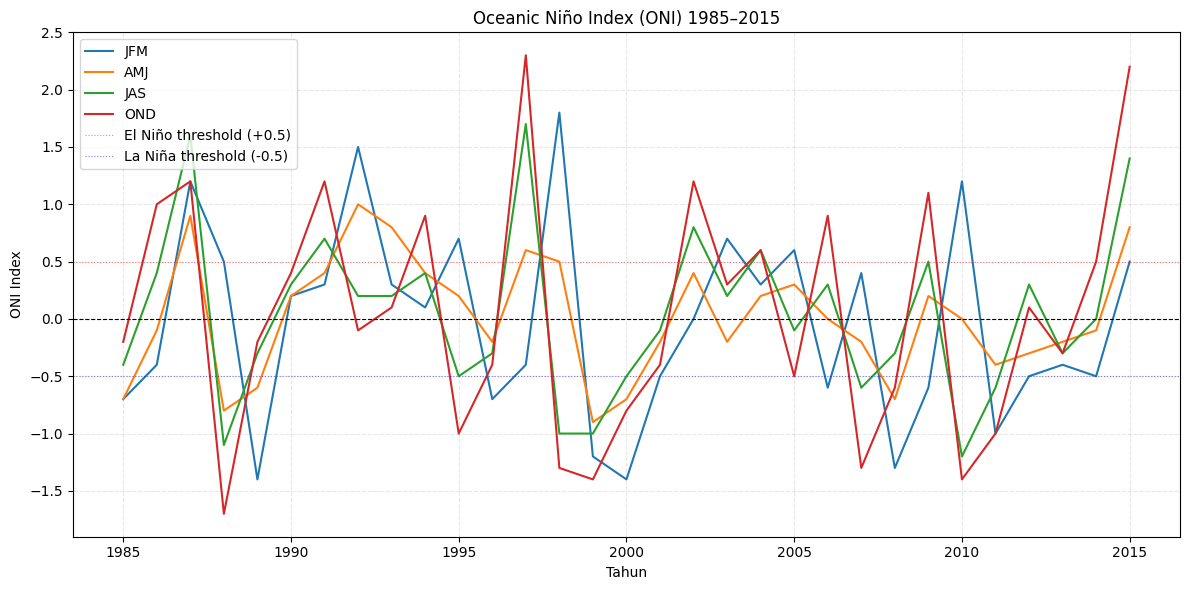

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(dataONI['Year'], dataONI['JFM'], label='JFM')
plt.plot(dataONI['Year'], dataONI['AMJ'], label='AMJ')
plt.plot(dataONI['Year'], dataONI['JAS'], label='JAS')
plt.plot(dataONI['Year'], dataONI['OND'], label='OND')

plt.axhline(0,    linestyle='--', color='black', linewidth=0.8)
plt.axhline(0.5,  linestyle=':',  color='red',   linewidth=0.8, alpha=0.5, label='El Niño threshold (+0.5)')
plt.axhline(-0.5, linestyle=':',  color='blue',  linewidth=0.8, alpha=0.5, label='La Niña threshold (-0.5)')

plt.xlabel('Tahun')
plt.ylabel('ONI Index')
plt.title('Oceanic Niño Index (ONI) 1985–2015')
plt.legend()
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Bagian 7: Kategorisasi Hujan

**Tujuan:** Mengubah nilai curah hujan (mm) menjadi kategori biner:
- `1` = **Hujan** → curah hujan > 0.5 mm/hari
- `0` = **Tidak Hujan** → curah hujan ≤ 0.5 mm/hari

Ambang batas 0.5 mm digunakan karena nilai di bawahnya dianggap embun atau noise sensor, bukan hujan yang signifikan secara meteorologis.

In [13]:
# 1 = hujan, 0 = tidak hujan
dataCH['Hujan'] = (dataCH['tp'] > 0.5).astype(int)

print(f"Total baris   : {len(dataCH):,}")
print(f"Hari hujan    : {dataCH['Hujan'].sum():,} ({dataCH['Hujan'].mean()*100:.1f}%)")
print(f"Tidak hujan   : {(dataCH['Hujan']==0).sum():,} ({(dataCH['Hujan']==0).mean()*100:.1f}%)")

dataCH

Total baris   : 5,264,730
Hari hujan    : 319,786 (6.1%)
Tidak hujan   : 4,944,944 (93.9%)


,valid_time,latitude,longitude,tp,Hujan
0,1985-01-01,-8.000000,118.000000,0.000000,0
1,1985-01-01,-8.000000,118.250000,0.007153,0
2,1985-01-01,-8.000000,118.500000,0.010967,0
3,1985-01-01,-8.000000,118.750000,0.000477,0
4,1985-01-01,-8.000000,119.000000,0.000000,0
...,...,...,...,...,...
5264725,2015-12-31,-11.500000,124.500000,0.003815,0
5264726,2015-12-31,-11.500000,124.750000,0.003338,0
5264727,2015-12-31,-11.500000,125.000000,0.000477,0
5264728,2015-12-31,-11.500000,125.250000,0.000000,0


---
## Bagian 8: Perhitungan Probabilitas Hujan per Musim (Agregat Spasial)

**Tujuan:** Menghitung probabilitas hujan rata-rata seluruh NTT per tahun per musim, yang akan dikorelasikan dengan ONI.

**Langkah:**
1. Parse kolom waktu → ekstrak tahun dan bulan
2. Kelompokkan bulan ke 4 musim
3. Hitung mean kolom `Hujan` per (Tahun × Musim) lalu kali 100 → hasilnya dalam persen (%)
4. Pivot tabel agar tiap musim jadi kolom tersendiri

> Di bagian ini seluruh titik grid NTT **dirata-rata menjadi 1 nilai** per tahun per musim. Khusus untuk korelasi dan regresi dengan ONI.

In [14]:
# Parse waktu
dataCH['valid_time'] = pd.to_datetime(dataCH['valid_time'])
dataCH['Year']  = dataCH['valid_time'].dt.year
dataCH['Month'] = dataCH['valid_time'].dt.month

# Fungsi musim
def get_musim(bulan):
    if bulan in [1, 2, 3]:   return 'JFM'
    elif bulan in [4, 5, 6]: return 'AMJ'
    elif bulan in [7, 8, 9]: return 'JAS'
    else:                    return 'OND'

dataCH['Season'] = dataCH['Month'].apply(get_musim)

# Hitung probabilitas rata-rata NTT per tahun per musim
hasilCH = (
    dataCH.groupby(['Year', 'Season'])['Hujan']
    .mean()
    .mul(100)         # → persen (0–100%)
    .reset_index()
)

# Pivot
hasilCH = hasilCH.pivot(
    index='Year',
    columns='Season',
    values='Hujan'
).reset_index()

# Rename dan reorder kolom
hasilCH = hasilCH.rename(columns={
    'JFM': 'CH_JFM',
    'AMJ': 'CH_AMJ',
    'JAS': 'CH_JAS',
    'OND': 'CH_OND'
})
hasilCH = hasilCH[['Year', 'CH_JFM', 'CH_AMJ', 'CH_JAS', 'CH_OND']]

print("Probabilitas Hujan Rata-rata NTT per Tahun per Musim (%)")
print(hasilCH.to_string(index=False))

Probabilitas Hujan Rata-rata NTT per Tahun per Musim (%)
 Year    CH_JFM   CH_AMJ   CH_JAS    CH_OND
 1985 12.884110 2.034739 0.058439  2.765311
 1986 16.410992 2.353775 1.383824  2.339878
 1987 15.677419 0.924022 0.060776  4.981300
 1988 15.758005 0.552995 0.331931  9.656381
 1989 15.904421 5.196739 0.374007  1.241234
 1990 18.379928 2.916224 0.093502  4.962599
 1991 17.218638 4.272717 0.023375  2.052361
 1992 11.189885 2.282878 0.046751  3.485273
 1993 12.422939 3.187995 0.042076  3.567087
 1994 19.734767 1.295049 0.035063  2.526882
 1995 23.204301 3.873331 0.086489  7.489481
 1996 15.644570 2.585372 0.070126 10.058439
 1997 16.310633 0.659341 0.016363  5.025713
 1998  9.264038 3.873331 1.715755  8.690977
 1999 24.186380 3.769349 0.058439  8.090229
 2000 23.055654 9.490724 0.032726  3.749416
 2001 17.080048 2.656268 0.299205  5.016363
 2002 13.995221 1.382488 0.126227  4.200561
 2003 16.606930 1.940210 0.014025  4.812997
 2004 11.038639 1.907125 0.011688  3.747078
 2005  8.497013 2.4

---
## Bagian 9: Penggabungan Data CH dan ONI

**Tujuan:** Menggabungkan tabel CH (`hasilCH`) dengan tabel ONI (`dataONI`) berdasarkan `Year`.

Hasilnya: tabel `gabung` dengan **31 baris** (1985–2015) × **9 kolom** (Year + 4 CH + 4 ONI).

In [15]:
gabung = pd.merge(hasilCH, dataONI, on='Year')

print(f"Shape tabel gabungan: {gabung.shape} (baris × kolom)")
print(f"Kolom: {list(gabung.columns)}")
display(gabung)

Shape tabel gabungan: (31, 9) (baris × kolom)
Kolom: ['Year', 'CH_JFM', 'CH_AMJ', 'CH_JAS', 'CH_OND', 'JFM', 'AMJ', 'JAS', 'OND']


,Year,CH_JFM,CH_AMJ,CH_JAS,CH_OND,JFM,AMJ,JAS,OND
0,1985,12.884110,2.034739,0.058439,2.765311,-0.700000,-0.700000,-0.400000,-0.200000
1,1986,16.410992,2.353775,1.383824,2.339878,-0.400000,-0.100000,0.400000,1.000000
2,1987,15.677419,0.924022,0.060776,4.981300,1.200000,0.900000,1.600000,1.200000
3,1988,15.758005,0.552995,0.331931,9.656381,0.500000,-0.800000,-1.100000,-1.700000
4,1989,15.904421,5.196739,0.374007,1.241234,-1.400000,-0.600000,-0.300000,-0.200000
5,1990,18.379928,2.916224,0.093502,4.962599,0.200000,0.200000,0.300000,0.400000
6,1991,17.218638,4.272717,0.023375,2.052361,0.300000,0.400000,0.700000,1.200000
7,1992,11.189885,2.282878,0.046751,3.485273,1.500000,1.000000,0.200000,-0.100000
8,1993,12.422939,3.187995,0.042076,3.567087,0.300000,0.800000,0.200000,0.100000
9,1994,19.734767,1.295049,0.035063,2.526882,0.100000,0.400000,0.400000,0.900000


---
## Bagian 10: Normalisasi Min-Max (Khusus Visualisasi Perbandingan)

**Tujuan:** Menyamakan skala CH (0–100%) dan ONI (-3 s/d +3) agar bisa digambar dalam satu grafik.

> ⚠️ **Penting:** Normalisasi ini **HANYA untuk visualisasi time series**.
> Data asli `gabung` tetap digunakan untuk korelasi dan regresi.
>
> **Mengapa ada nilai 0.0?**
> Nilai 0.0 setelah normalisasi bukan berarti tidak ada hujan atau ONI = 0.
> Artinya nilai tersebut adalah **yang terkecil** dalam periode 1985–2015.
>
> Contoh: CH_AMJ 1988 = 31.26% (asli), normalisasi = 0.0 → karena 31.26% adalah nilai terkecil di kolom CH_AMJ seluruh periode.
> ONI OND 1988 = -1.7 (asli), normalisasi = 0.0 → karena -1.7 adalah nilai terkecil di kolom OND.

In [16]:
scaler = MinMaxScaler()

cols_to_normalize = ['CH_JFM', 'CH_AMJ', 'CH_JAS', 'CH_OND',
                     'JFM', 'AMJ', 'JAS', 'OND']

gabung_norm = gabung.copy()
gabung_norm[cols_to_normalize] = scaler.fit_transform(gabung[cols_to_normalize])

print("Data setelah normalisasi (skala 0–1):")
print("(0.0 = nilai terkecil dalam periode, 1.0 = nilai terbesar)")
display(gabung_norm.head())

Data setelah normalisasi (skala 0–1):
(0.0 = nilai terkecil dalam periode, 1.0 = nilai terbesar)


,Year,CH_JFM,CH_AMJ,CH_JAS,CH_OND,JFM,AMJ,JAS,OND
0,1985,0.285498,0.165785,0.018433,0.149404,0.218750,0.105263,0.275862,0.375000
1,1986,0.508459,0.201481,0.541014,0.107699,0.312500,0.421053,0.551724,0.675000
2,1987,0.462085,0.041512,0.019355,0.366636,0.812500,0.947368,0.965517,0.725000
3,1988,0.467179,0.000000,0.126267,0.824931,0.593750,0.052632,0.034483,0.000000
4,1989,0.476435,0.519566,0.142857,0.000000,0.000000,0.157895,0.310345,0.375000


**Tujuan:** Memvisualisasikan perbandingan tren CH dan ONI per musim dalam 4 subplot (1 frame).

- Garis **solid** = Probabilitas Hujan (CH)
- Garis **putus-putus** = Indeks ONI
- Garis **titik-titik abu-abu** di 0.5 = nilai tengah normalisasi

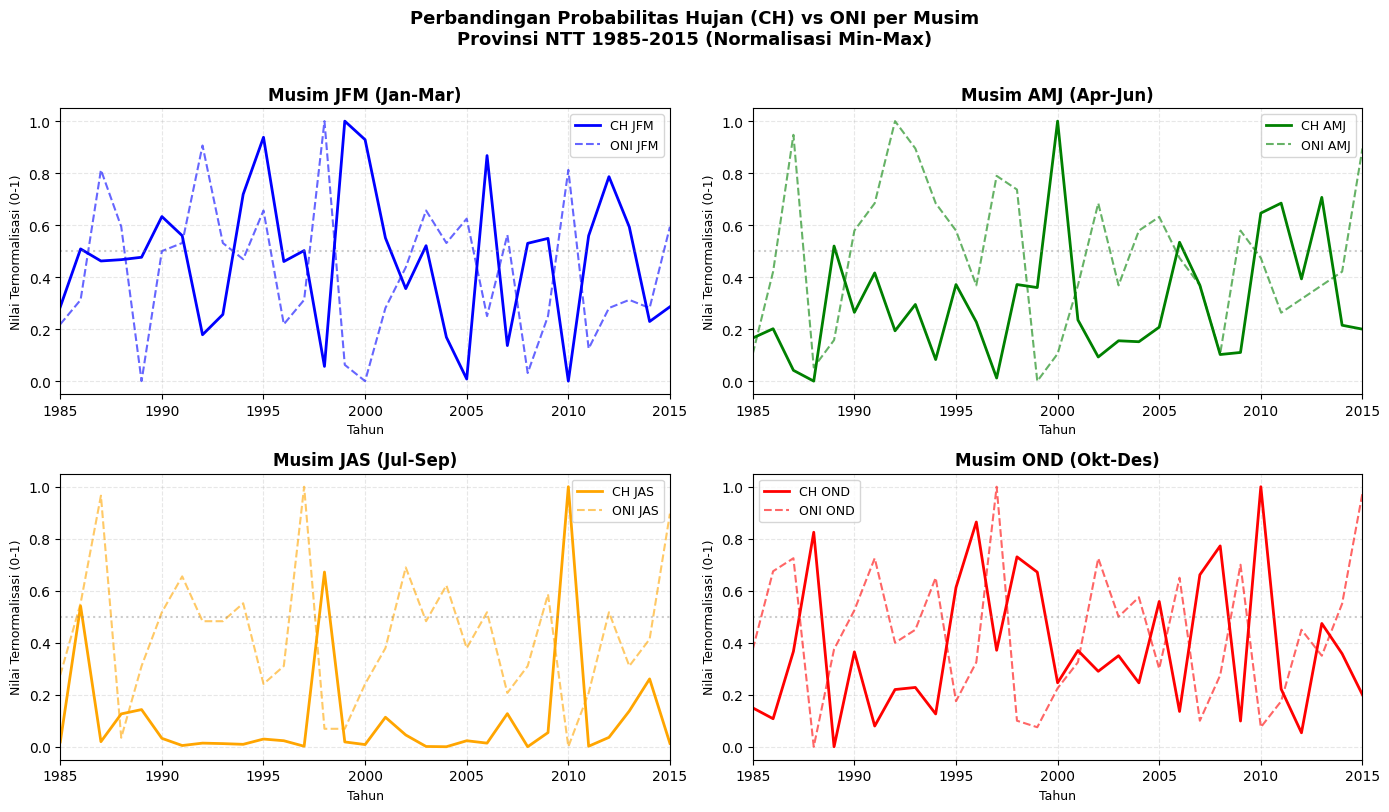

Gambar tersimpan: CH_vs_ONI_per_musim.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

musim_list  = ['JFM', 'AMJ', 'JAS', 'OND']
colors      = ['blue', 'green', 'orange', 'red']
label_musim = {'JFM': 'Jan-Mar', 'AMJ': 'Apr-Jun', 'JAS': 'Jul-Sep', 'OND': 'Okt-Des'}

for i, (s, color) in enumerate(zip(musim_list, colors)):
    ax = axes[i]
    ax.plot(gabung_norm['Year'], gabung_norm[f'CH_{s}'],
            label=f'CH {s}', color=color, linewidth=2)
    ax.plot(gabung_norm['Year'], gabung_norm[s],
            label=f'ONI {s}', color=color, linewidth=1.5, linestyle='--', alpha=0.6)
    ax.axhline(0.5, linestyle=':', color='gray', alpha=0.4)
    ax.set_title(f'Musim {s} ({label_musim[s]})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tahun', fontsize=9)
    ax.set_ylabel('Nilai Ternormalisasi (0-1)', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(1985, 2015)

fig.suptitle(
    'Perbandingan Probabilitas Hujan (CH) vs ONI per Musim\n'
    'Provinsi NTT 1985-2015 (Normalisasi Min-Max)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('CH_vs_ONI_per_musim.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gambar tersimpan: CH_vs_ONI_per_musim.png")

---
## Bagian 11: Analisis Korelasi CH vs ONI — Heatmap

**Tujuan:** Menghitung dan memvisualisasikan kekuatan hubungan CH dan ONI dengan **korelasi Pearson**.

**Cara membaca heatmap:**
- Nilai mendekati **-1** (biru) → saat ONI naik (El Niño), hujan turun
- Nilai mendekati **+1** (merah) → saat ONI naik, hujan naik
- Nilai mendekati **0** → tidak ada hubungan jelas

> Data yang digunakan: `gabung` (nilai asli dalam %), **bukan** `gabung_norm`.

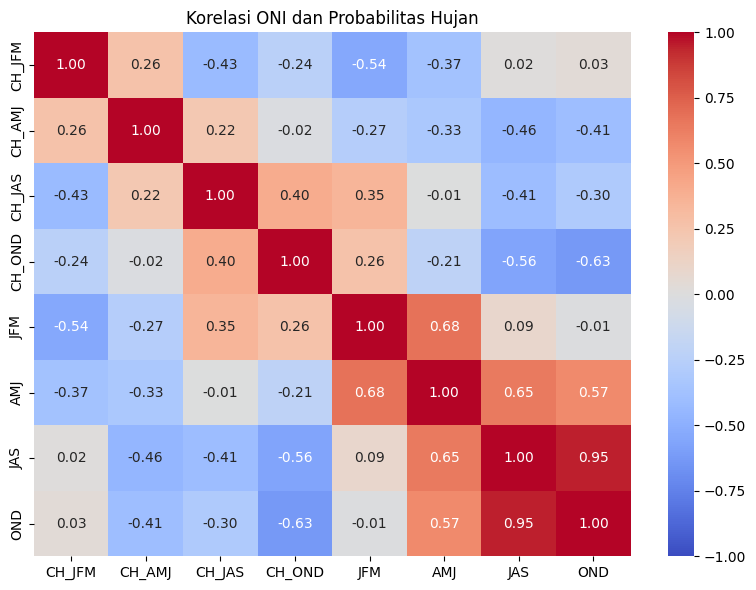

Gambar tersimpan: heatmap_korelasi.png


In [18]:
corr_focus = gabung[
    ['CH_JFM', 'CH_AMJ', 'CH_JAS', 'CH_OND',
     'JFM', 'AMJ', 'JAS', 'OND']
].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_focus, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Korelasi ONI dan Probabilitas Hujan')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gambar tersimpan: heatmap_korelasi.png")

---
## Bagian 12: Load Shapefile Batas Wilayah

**Tujuan:** Membaca shapefile batas wilayah administrasi Indonesia untuk di-overlay di peta.

In [19]:
indo = gpd.read_file('indonesia_kab.shp')
print(f"Shapefile berhasil dimuat. Jumlah fitur: {len(indo)}")
print(f"CRS (sistem koordinat): {indo.crs}")

Shapefile berhasil dimuat. Jumlah fitur: 439
CRS (sistem koordinat): EPSG:4326


---
## Bagian 13: Perhitungan Probabilitas Hujan per Titik Grid (untuk Peta)

**Tujuan:** Menghitung probabilitas hujan per kombinasi **Tahun × Musim × Titik Grid (lat × lon)** untuk membuat peta dan diekspor ke dashboard.

Berbeda dengan Bagian 8 yang merata-rata seluruh NTT, bagian ini **mempertahankan informasi spasial** setiap titik grid.

> ✅ **Bug fix dari versi sebelumnya:**
> - Tidak ada konversi `tp × 1000` ulang di sini (sudah dilakukan di Bagian 5 dengan proteksi dobel)
> - Kolom `Season` dan `Year` sudah tersedia dari Bagian 8 — tidak perlu dibuat ulang
> - Hasil `Hujan` sudah dalam persen (×100) yang benar → nilai peta antara 0–100%, bukan 0–1%

In [20]:
# Hitung probabilitas per titik grid
# Kolom Season, Year, Hujan sudah tersedia dari Bagian 7 dan 8
spasial = (
    dataCH.groupby(
        ['Year', 'Season', 'latitude', 'longitude']
    )['Hujan']
    .mean()
    .mul(100)    # → persen (0–100%)
    .reset_index()
)

print(f"Shape data spasial  : {spasial.shape}")
print(f"Rentang probabilitas: {spasial['Hujan'].min():.2f}% – {spasial['Hujan'].max():.2f}%")
print(f"Rata-rata           : {spasial['Hujan'].mean():.2f}%")
print()

# Verifikasi nilai 1988 AMJ (harus sekitar 31%, bukan 0%)
cek = spasial[(spasial['Year'] == 1988) & (spasial['Season'] == 'AMJ')]
print(f"Verifikasi 1988 AMJ → rata-rata: {cek['Hujan'].mean():.2f}%")
print("(Nilai ini harus sekitar 31%, bukan mendekati 0)")

display(spasial.head(10))

Shape data spasial  : (57660, 5)
Rentang probabilitas: 0.00% – 52.22%
Rata-rata           : 6.11%

Verifikasi 1988 AMJ → rata-rata: 0.55%
(Nilai ini harus sekitar 31%, bukan mendekati 0)


,Year,Season,latitude,longitude,Hujan
0,1985,AMJ,-11.500000,118.000000,4.395604
1,1985,AMJ,-11.500000,118.250000,3.296703
2,1985,AMJ,-11.500000,118.500000,4.395604
3,1985,AMJ,-11.500000,118.750000,2.197802
4,1985,AMJ,-11.500000,119.000000,2.197802
5,1985,AMJ,-11.500000,119.250000,2.197802
6,1985,AMJ,-11.500000,119.500000,3.296703
7,1985,AMJ,-11.500000,119.750000,4.395604
8,1985,AMJ,-11.500000,120.000000,4.395604
9,1985,AMJ,-11.500000,120.250000,6.593407


---
## Bagian 14: Visualisasi Peta Spasial Probabilitas Hujan

**Tujuan:** Membuat peta sebaran spasial probabilitas hujan di seluruh NTT untuk setiap kombinasi tahun dan musim.

**Layout:** Baris = tahun (5 tahun per frame), Kolom = 4 musim (JFM, AMJ, JAS, OND)

**Cara membaca warna:**
- **Biru** → probabilitas hujan tinggi (sering hujan)
- **Merah/kuning** → probabilitas hujan rendah (jarang hujan)

Total: 31 tahun × 4 musim = 124 peta, dibagi menjadi 7 frame (5 tahun per frame).

> ✅ Skala warna ditetapkan **0–100%** secara konsisten di semua frame agar perbandingan antar tahun valid.

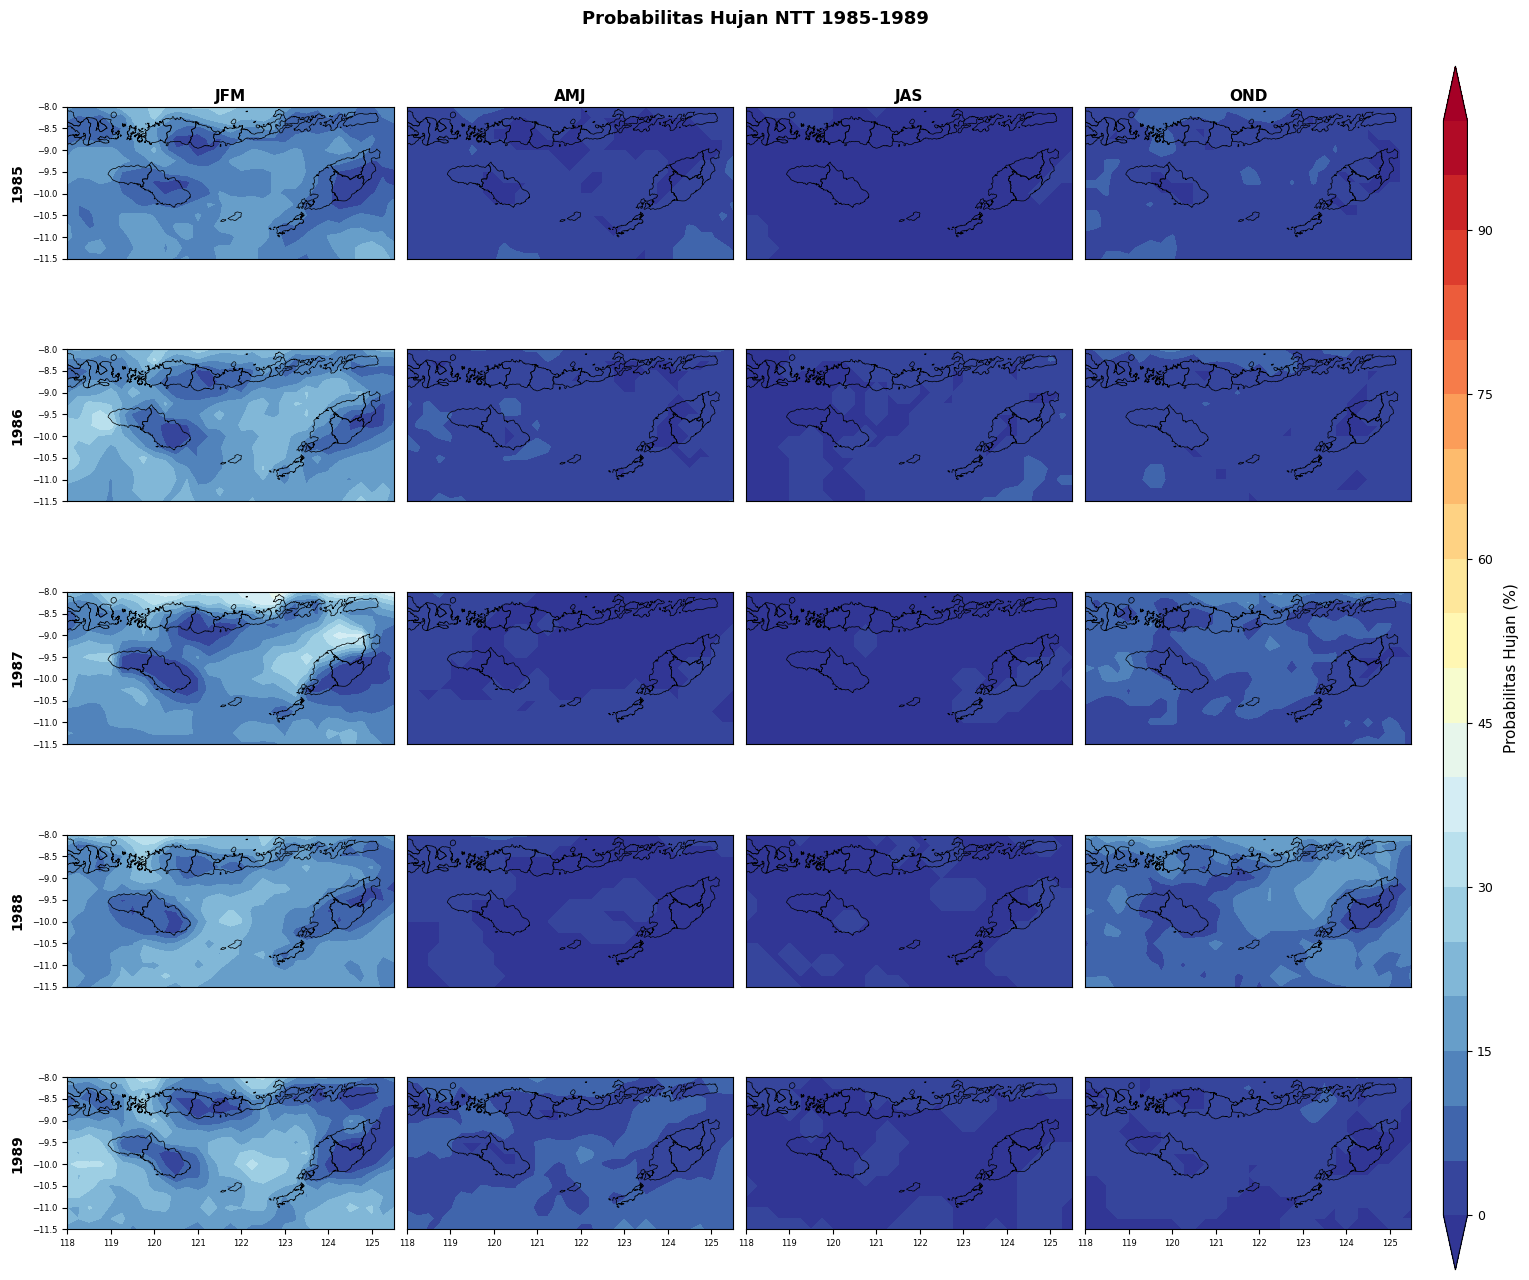

Tersimpan: Frame_1.png


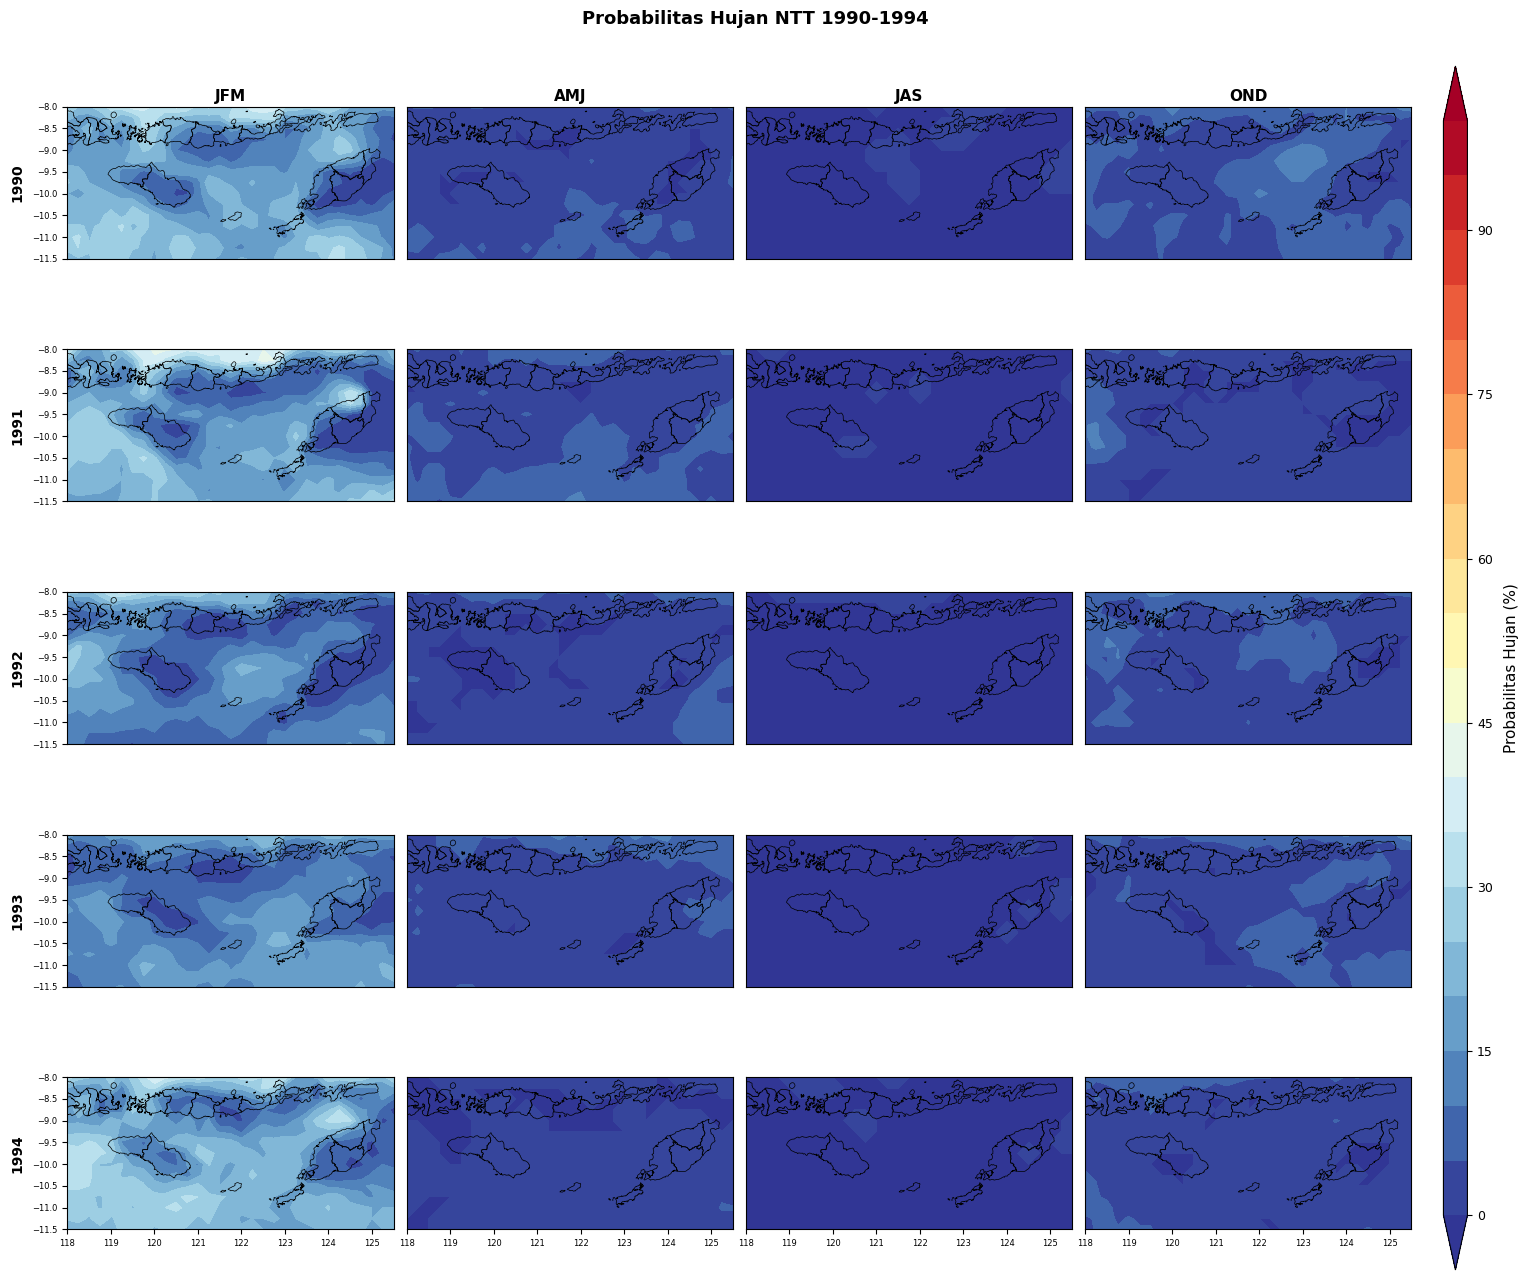

Tersimpan: Frame_2.png


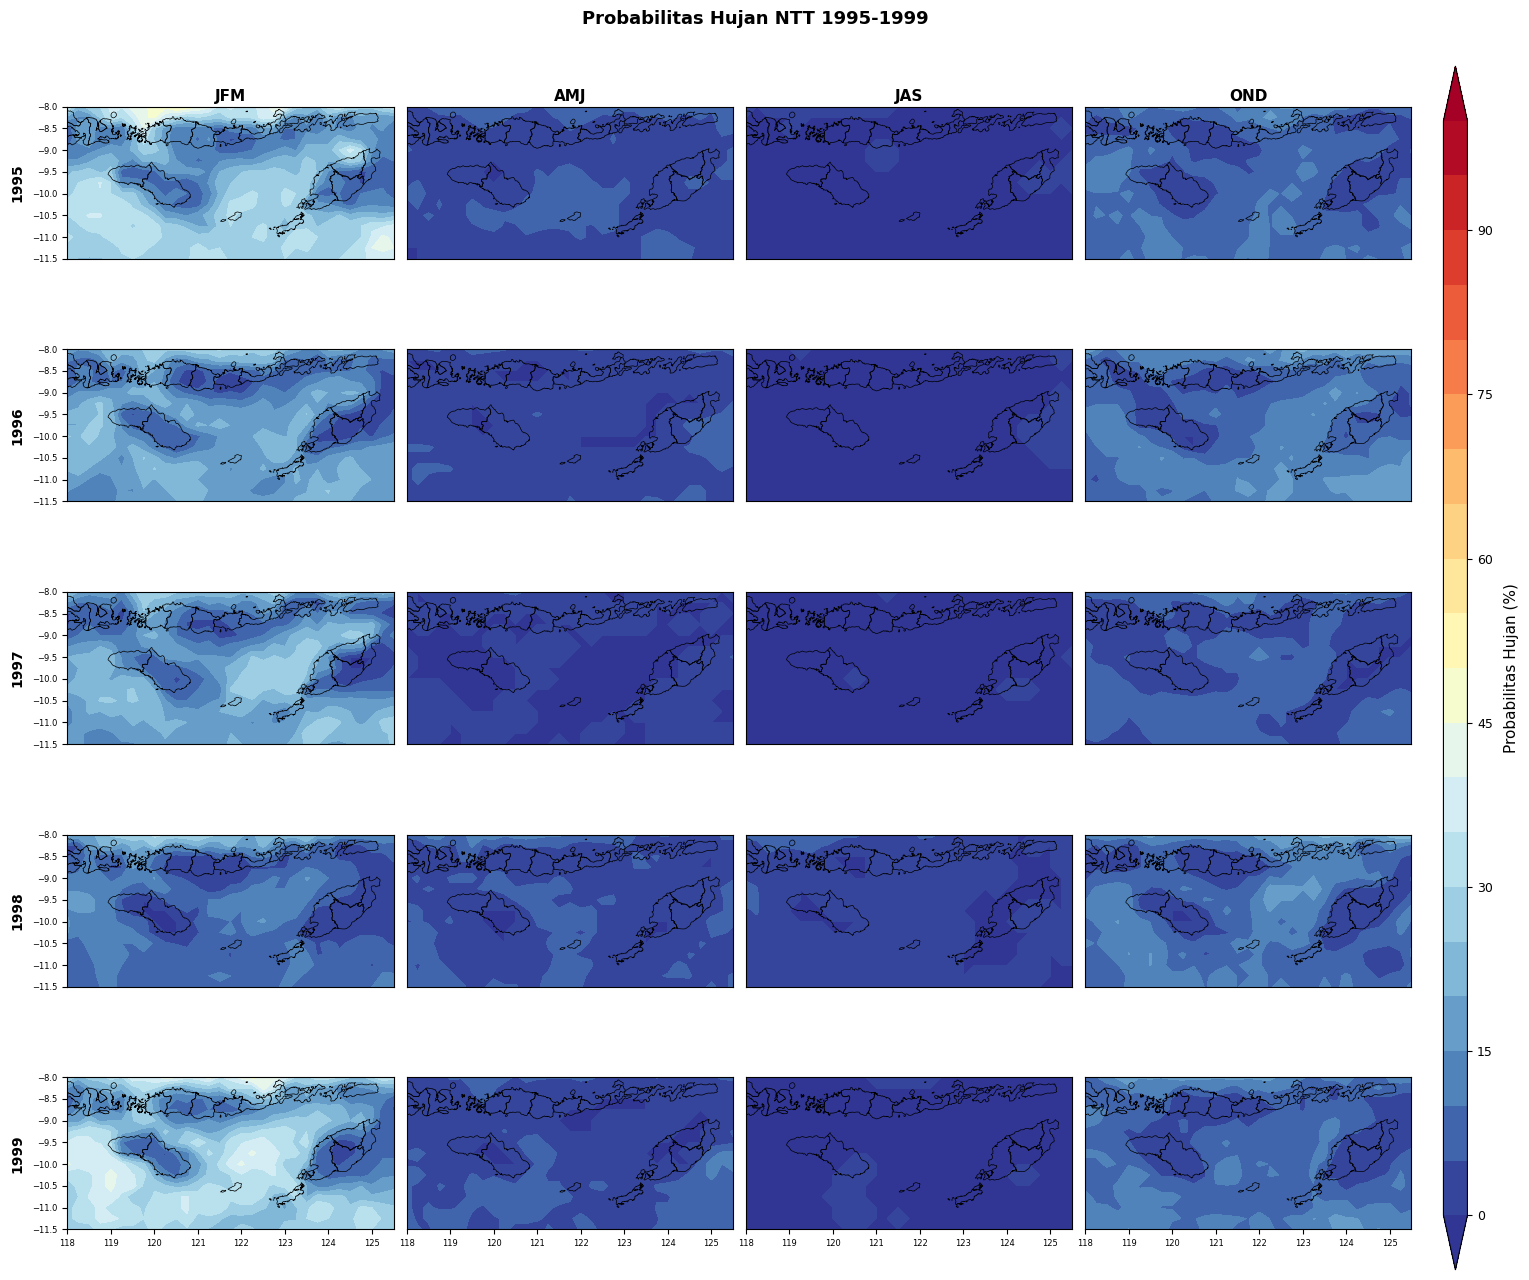

Tersimpan: Frame_3.png


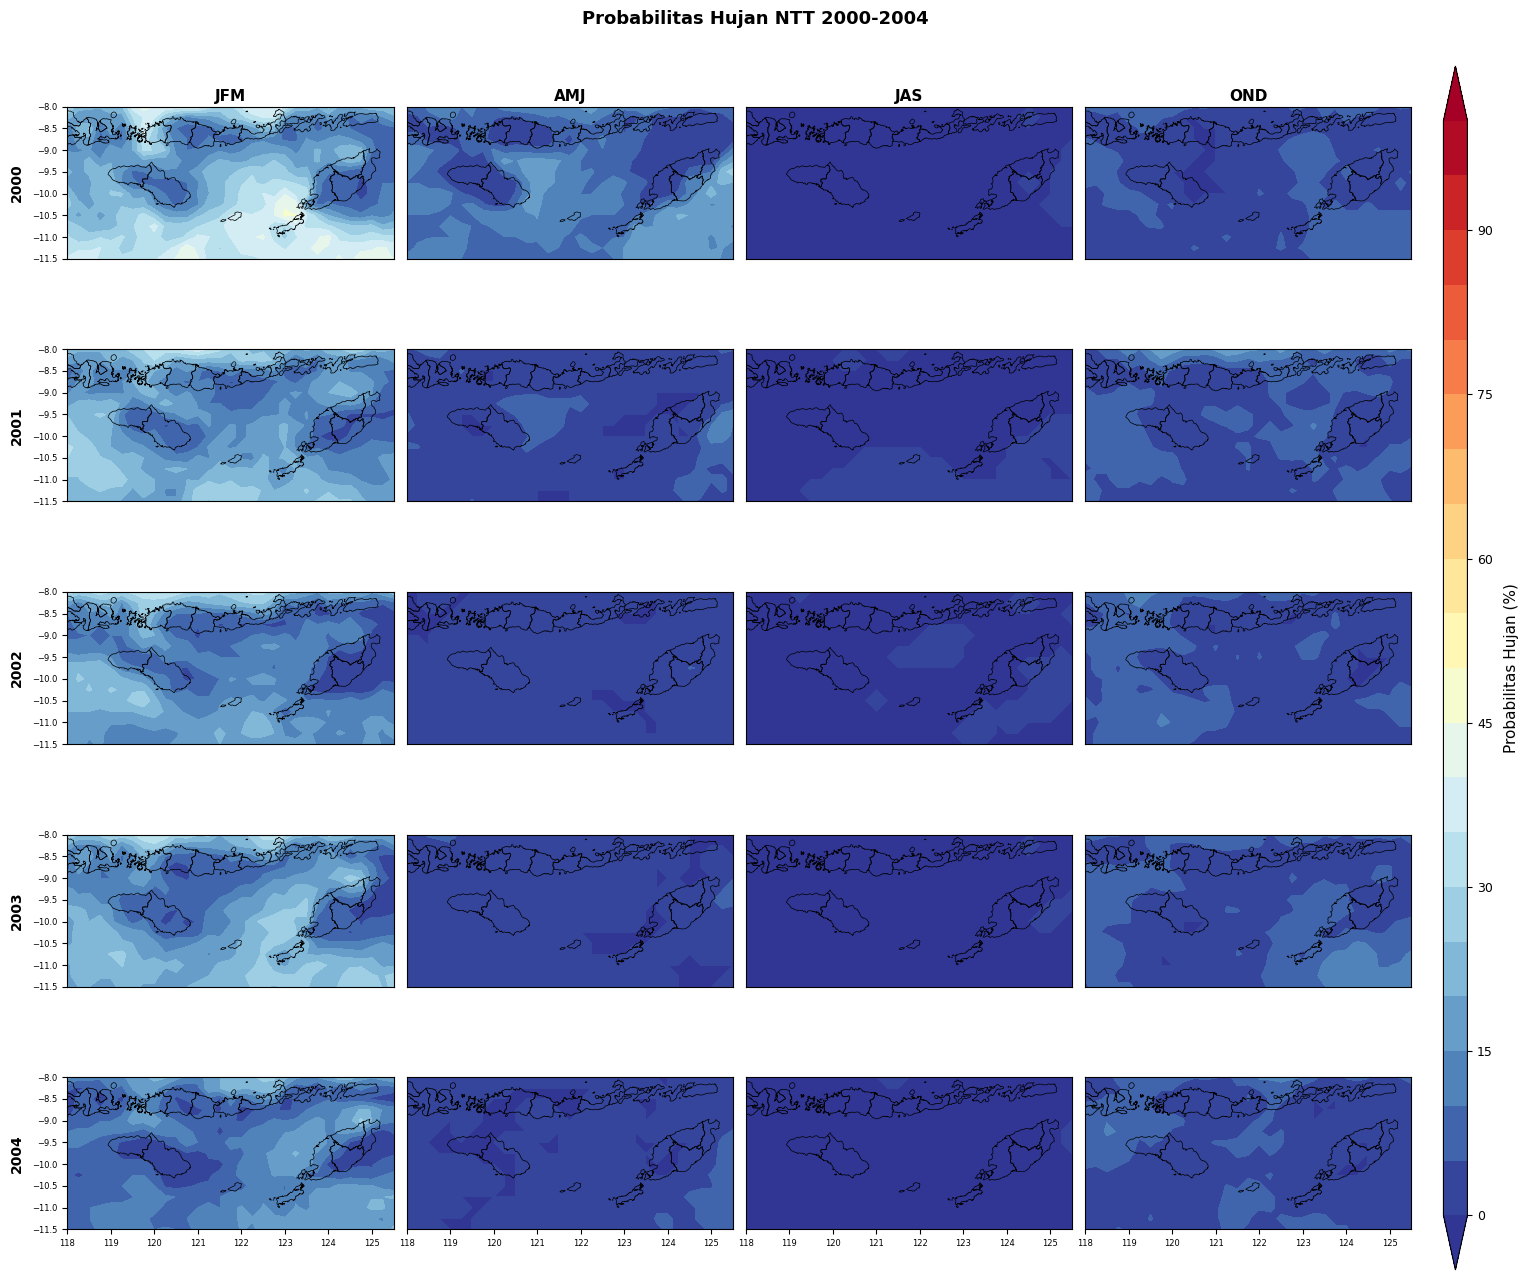

Tersimpan: Frame_4.png


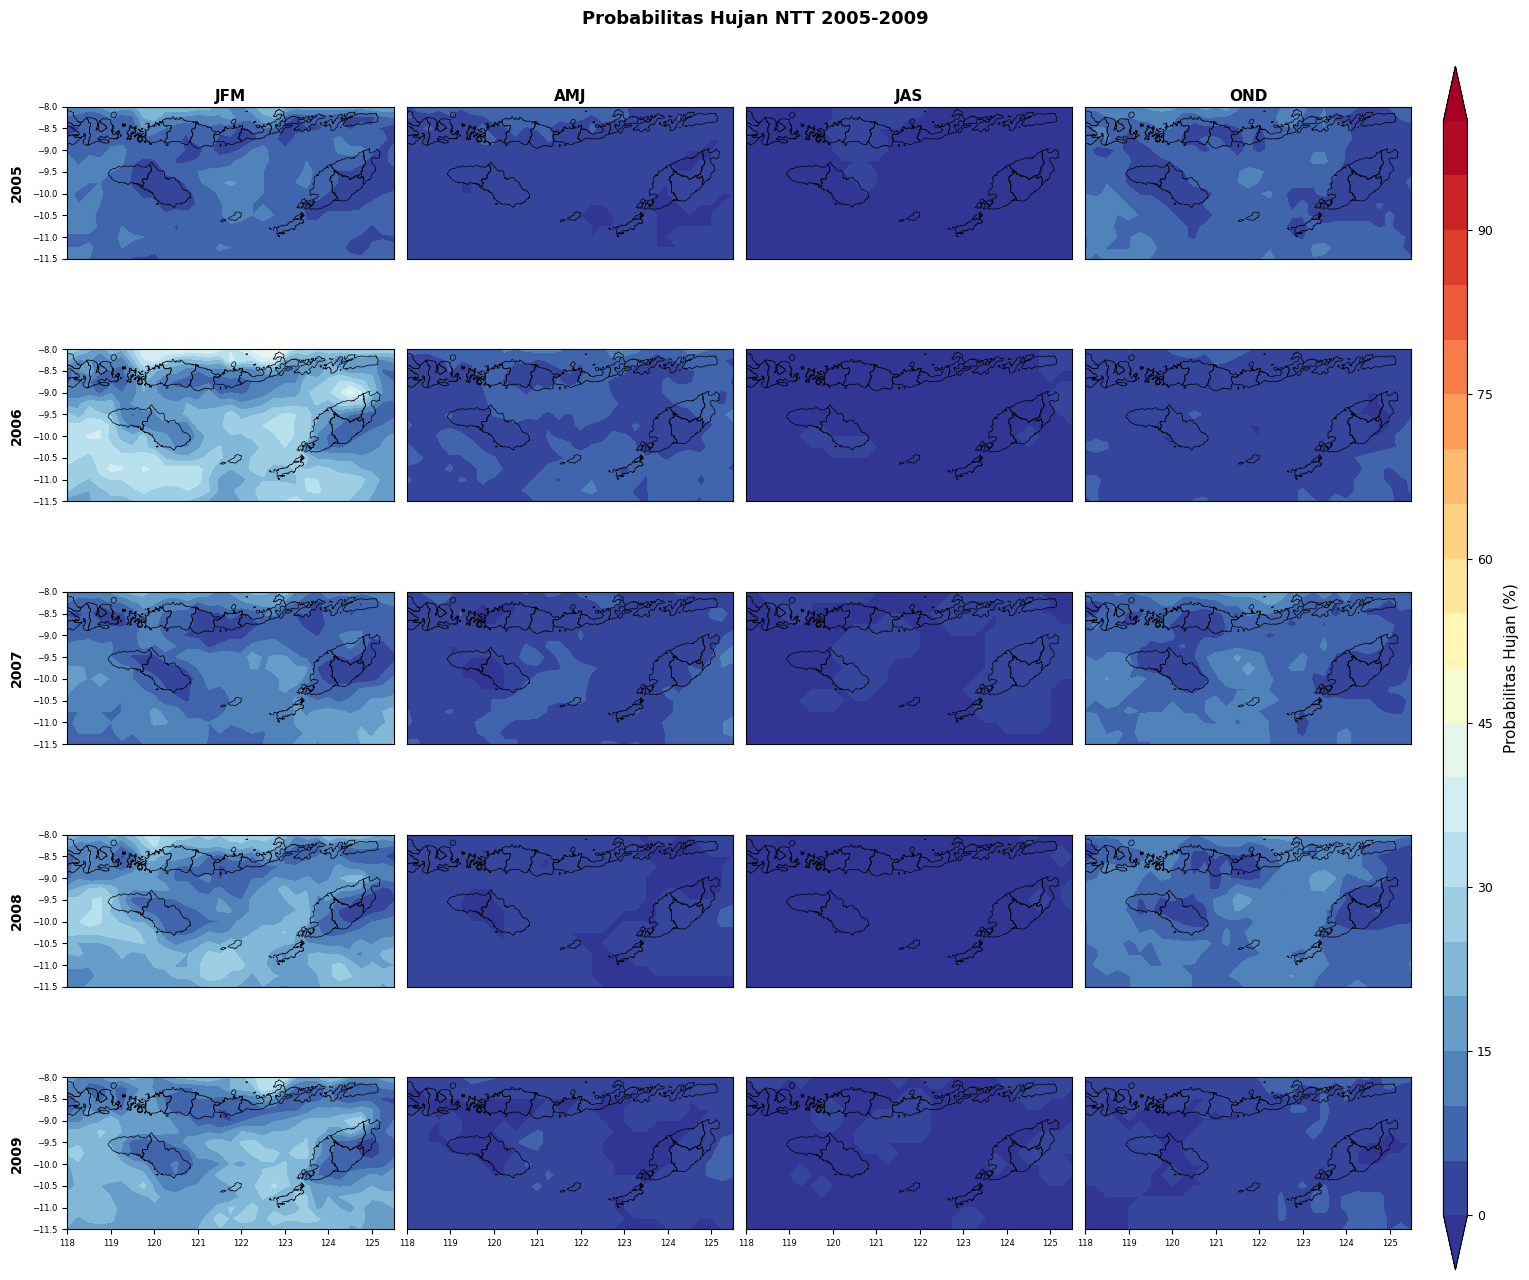

Tersimpan: Frame_5.png


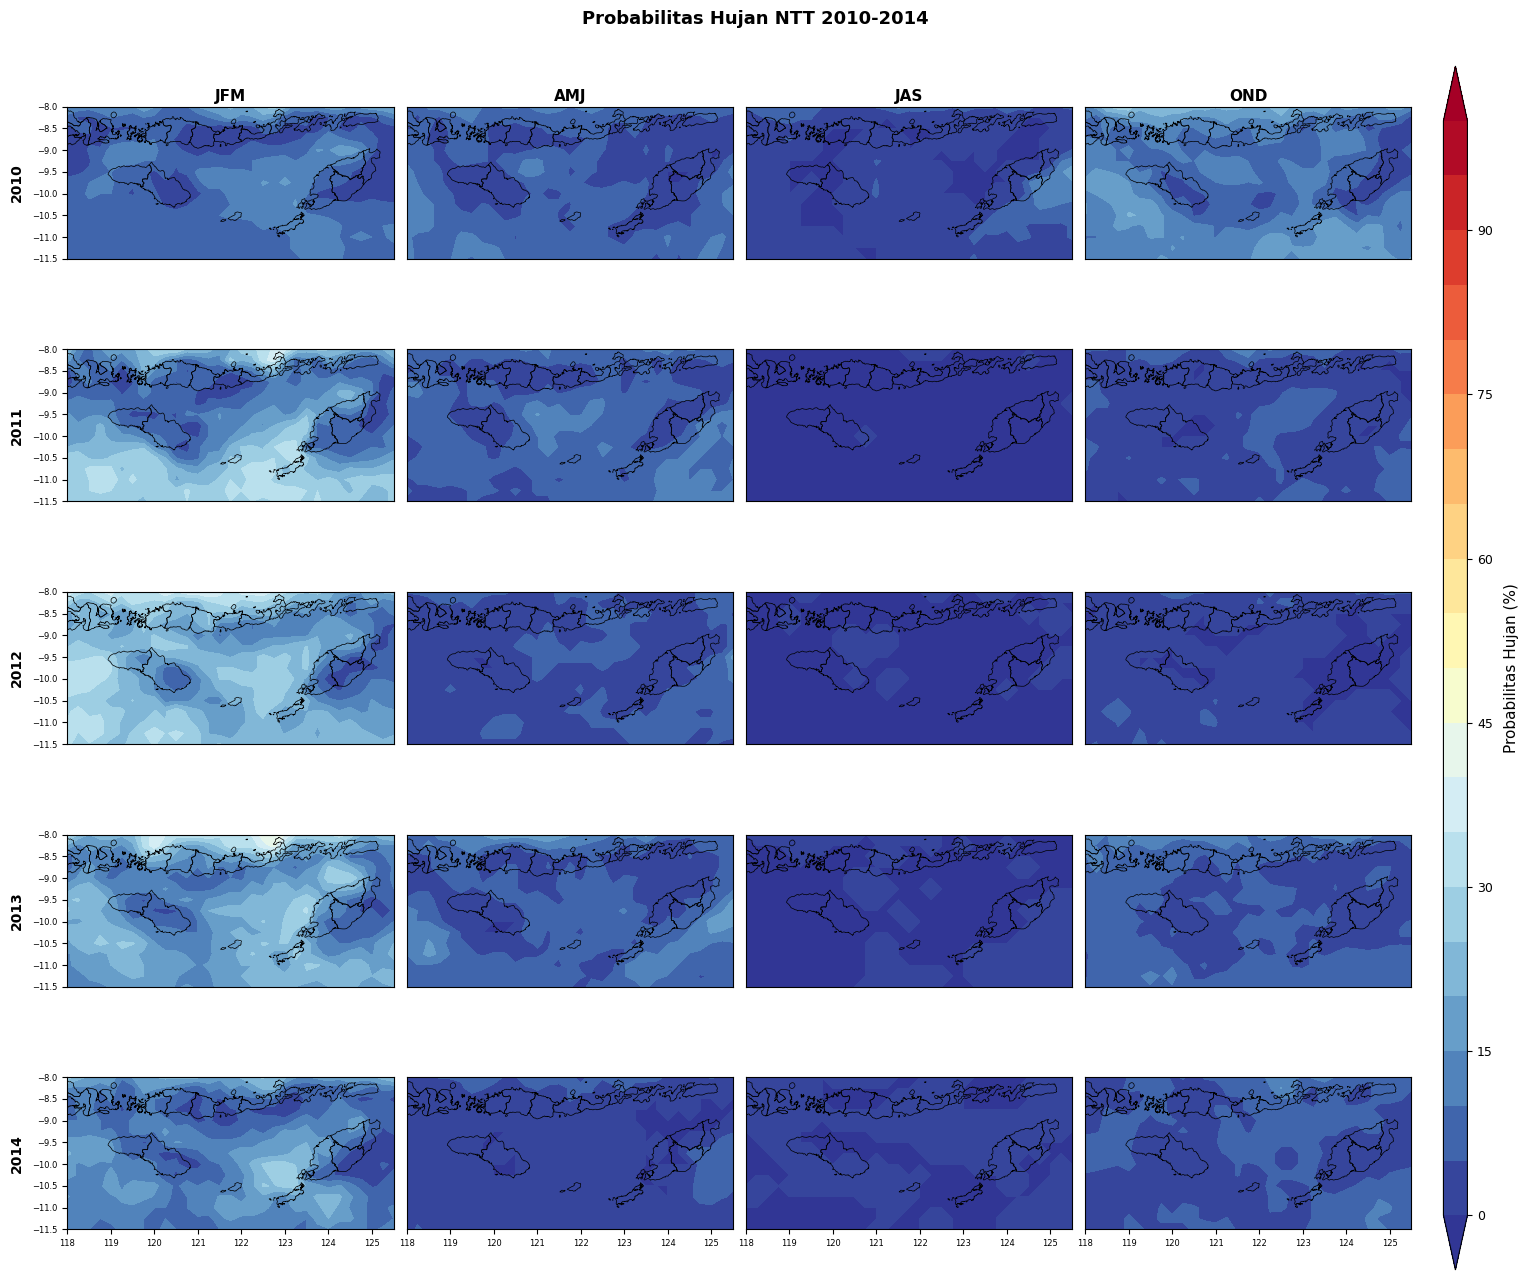

Tersimpan: Frame_6.png


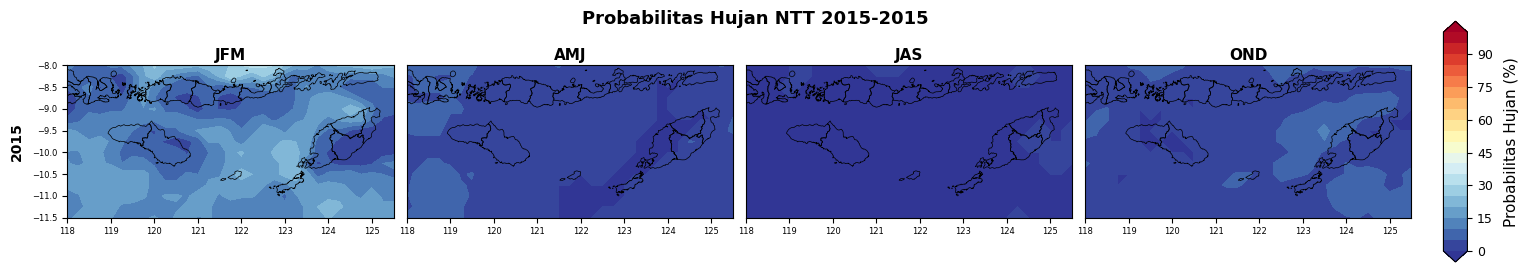

Tersimpan: Frame_7.png


In [21]:
urutan_musim   = ['JFM', 'AMJ', 'JAS', 'OND']
semua_tahun    = sorted(spasial['Year'].unique())
tahun_per_frame = 5

for frame_idx, start in enumerate(range(0, len(semua_tahun), tahun_per_frame)):

    tahun_list = semua_tahun[start:start + tahun_per_frame]
    nrows = len(tahun_list)
    ncols = 4

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 2.8))

    if nrows == 1:
        axes = axes[np.newaxis, :]

    im = None

    for row_idx, tahun in enumerate(tahun_list):
        for col_idx, musim in enumerate(urutan_musim):

            ax = axes[row_idx, col_idx]

            subset = spasial[
                (spasial['Year'] == tahun) &
                (spasial['Season'] == musim)
            ]

            if subset.empty:
                ax.set_visible(False)
                continue

            pivot = subset.pivot(
                index='latitude',
                columns='longitude',
                values='Hujan'
            ).sort_index()

            lon = pivot.columns.values
            lat = pivot.index.values
            Lon, Lat = np.meshgrid(lon, lat)
            Z = pivot.values

            # Skala warna konsisten 0–100% di semua frame
            im = ax.contourf(
                Lon, Lat, Z,
                levels=np.linspace(0, 100, 21),
                cmap='RdYlBu_r',
                extend='both'
            )

            indo.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

            ax.set_xlim(lon.min(), lon.max())
            ax.set_ylim(lat.min(), lat.max())
            ax.margins(0)
            ax.set_aspect('equal')
            ax.tick_params(labelsize=6)

            if row_idx == 0:
                ax.set_title(musim, fontsize=11, fontweight='bold', pad=4)

            if col_idx == 0:
                ax.set_ylabel(str(tahun), fontsize=10, fontweight='bold',
                              rotation=90, labelpad=6)
            else:
                ax.set_ylabel('')

            ax.set_xlabel('')
            ax.tick_params(
                left=(col_idx == 0), bottom=(row_idx == nrows - 1),
                labelleft=(col_idx == 0), labelbottom=(row_idx == nrows - 1),
                labelsize=6
            )

    fig.subplots_adjust(
        left=0.07, right=0.91, top=0.94, bottom=0.08,
        wspace=0.04, hspace=0.04
    )

    if im is not None:
        cax  = fig.add_axes([0.93, 0.08, 0.015, 0.86])
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Probabilitas Hujan (%)', fontsize=11, labelpad=8)
        cbar.ax.tick_params(labelsize=9)

    tahun_awal  = tahun_list[0]
    tahun_akhir = tahun_list[-1]
    fig.suptitle(
        f'Probabilitas Hujan NTT {tahun_awal}-{tahun_akhir}',
        fontsize=13, fontweight='bold', y=0.98
    )

    fname = f'Frame_{frame_idx + 1}.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Tersimpan: {fname}")

---
## Bagian 15: Regresi Linear ONI vs Probabilitas Hujan

**Tujuan:** Menghitung dan memvisualisasikan regresi linear ONI terhadap probabilitas hujan rata-rata NTT per musim.

- **X (prediktor):** Nilai ONI per musim
- **Y (respons):** Probabilitas hujan rata-rata NTT per musim (%)
- **Model:** `y = a·x + b`
- **Kemiringan (a) negatif** → saat ONI naik (El Niño), probabilitas hujan turun

> Data yang digunakan: `spasial` → dirata-rata per (Year × Season) → 31 pasangan data per musim.

Total data: 124 baris (31 tahun × 4 musim)



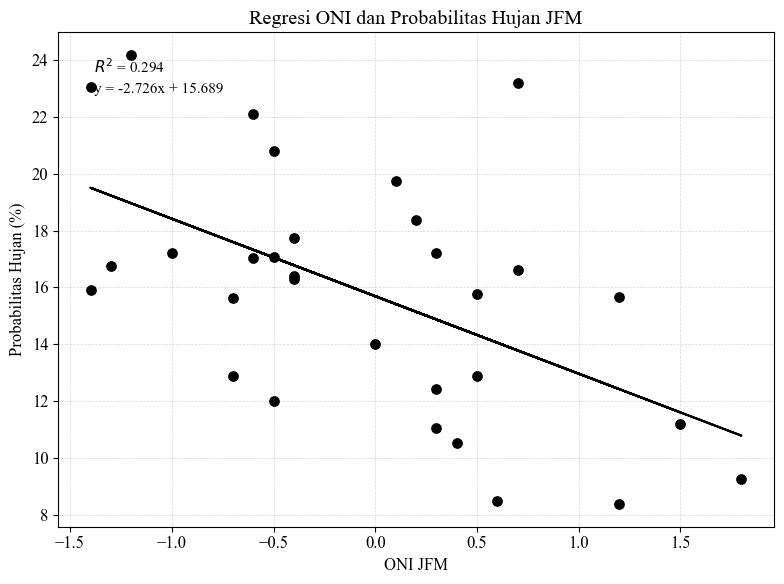

=== JFM ===
Persamaan Regresi : y = -2.726x + 15.689
R²                : 0.294
Kemiringan (a)    : -2.726
Intercept (b)     : 15.689



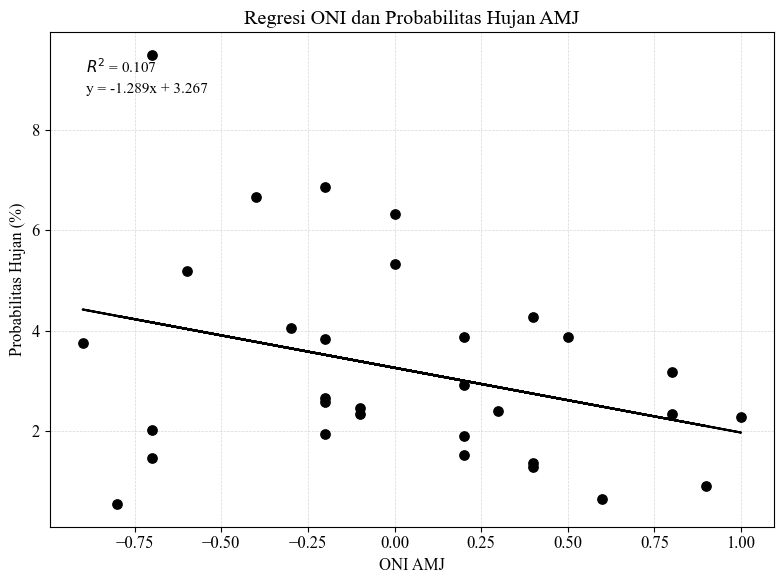

=== AMJ ===
Persamaan Regresi : y = -1.289x + 3.267
R²                : 0.107
Kemiringan (a)    : -1.289
Intercept (b)     : 3.267



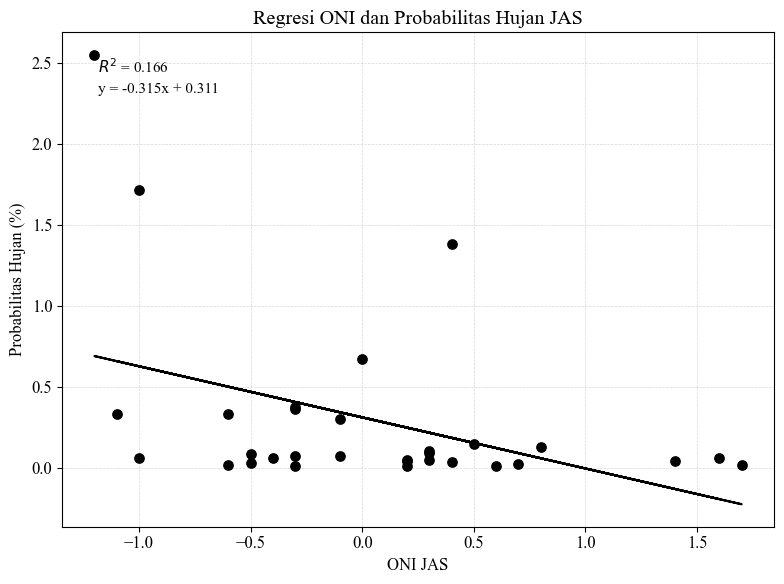

=== JAS ===
Persamaan Regresi : y = -0.315x + 0.311
R²                : 0.166
Kemiringan (a)    : -0.315
Intercept (b)     : 0.311



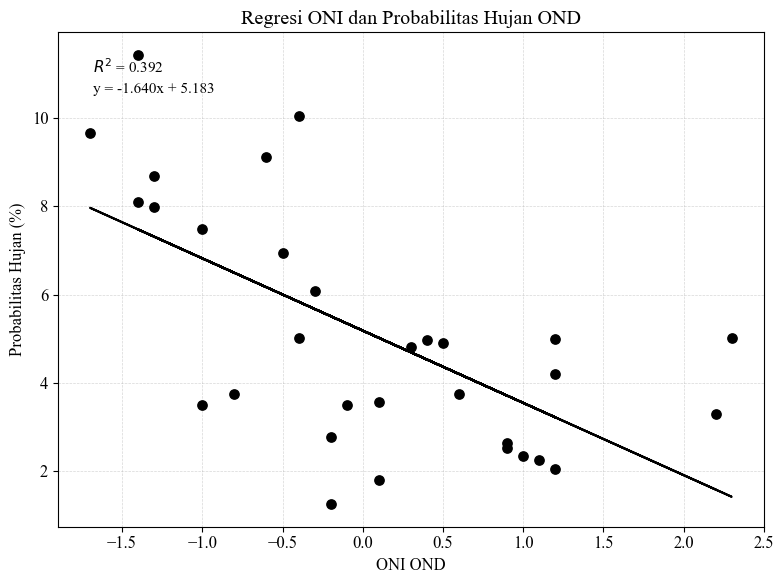

=== OND ===
Persamaan Regresi : y = -1.640x + 5.183
R²                : 0.392
Kemiringan (a)    : -1.640
Intercept (b)     : 5.183



In [22]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size']   = 12

# Rata-rata spasial per Year × Season
rata_hujan = (
    spasial.groupby(['Year', 'Season'])['Hujan']
    .mean()
    .reset_index()
)

# Ubah ONI ke format long agar bisa di-merge
oni_long = dataONI.melt(
    id_vars='Year',
    value_vars=['JFM', 'AMJ', 'JAS', 'OND'],
    var_name='Season',
    value_name='ONI'
)

gabung_regresi = pd.merge(rata_hujan, oni_long, on=['Year', 'Season'])
print(f"Total data: {len(gabung_regresi)} baris ({len(gabung_regresi)//4} tahun × 4 musim)")
print()

for musim in ['JFM', 'AMJ', 'JAS', 'OND']:

    subset = gabung_regresi[gabung_regresi['Season'] == musim]

    X      = subset[['ONI']]
    y      = subset['Hujan']

    model  = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    r2        = r2_score(y, y_pred)
    a         = model.coef_[0]
    b         = model.intercept_
    persamaan = f'y = {a:.3f}x + {b:.3f}'

    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color='black', s=45, zorder=3)
    plt.plot(X, y_pred, color='black', linewidth=1.5)

    plt.text(0.05, 0.95, f'$R^2$ = {r2:.3f}',
             transform=plt.gca().transAxes, fontsize=11, verticalalignment='top')
    plt.text(0.05, 0.90, persamaan,
             transform=plt.gca().transAxes, fontsize=11, verticalalignment='top')

    plt.title(f'Regresi ONI dan Probabilitas Hujan {musim}')
    plt.xlabel(f'ONI {musim}')
    plt.ylabel('Probabilitas Hujan (%)')
    plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'regresi_{musim}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'=== {musim} ===')
    print(f'Persamaan Regresi : {persamaan}')
    print(f'R²                : {r2:.3f}')
    print(f'Kemiringan (a)    : {a:.3f}')
    print(f'Intercept (b)     : {b:.3f}')
    print()

---
## Bagian 16: Ekspor Data Spasial untuk Dashboard

**Tujuan:** Menyimpan tabel `spasial` ke `spasial_data.csv` untuk dashboard Streamlit.

File ini berisi:
- `Year` → tahun (1985–2015)
- `Season` → musim (JFM / AMJ / JAS / OND)
- `latitude`, `longitude` → koordinat titik grid
- `Hujan` → probabilitas hujan dalam **persen (0–100%)** ✅

> ✅ Nilai sudah benar karena melewati proteksi dobel konversi di Bagian 5.

In [23]:
spasial.to_csv('spasial_data.csv', index=False)

print("spasial_data.csv berhasil diekspor untuk Dashboard!")
print(f"   Jumlah baris  : {len(spasial):,}")
print(f"   Rentang nilai : {spasial['Hujan'].min():.2f}% - {spasial['Hujan'].max():.2f}%")
print(f"   Rata-rata     : {spasial['Hujan'].mean():.2f}%")
print()
print("Cuplikan data:")
display(spasial.head())

spasial_data.csv berhasil diekspor untuk Dashboard!
   Jumlah baris  : 57,660
   Rentang nilai : 0.00% - 52.22%
   Rata-rata     : 6.11%

Cuplikan data:


,Year,Season,latitude,longitude,Hujan
0,1985,AMJ,-11.500000,118.000000,4.395604
1,1985,AMJ,-11.500000,118.250000,3.296703
2,1985,AMJ,-11.500000,118.500000,4.395604
3,1985,AMJ,-11.500000,118.750000,2.197802
4,1985,AMJ,-11.500000,119.000000,2.197802
